## Preparation

In [1]:
import torch
from models_arch.Recognizer import RecognizerV3ker5
from utils.randimage import RandomLinesGenerator
import matplotlib.pyplot as plt

In [2]:
model = RecognizerV3ker5()
state_dict = torch.load('trained_models/RecognizerV3ker5.pth', weights_only=True)
model.load_state_dict(state_dict)

class_mapper: dict = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
    5: '5',
    6: '6',
    7: '7',
    8: '8',
    9: '9',
    10: 'blank',
}

## Visualize the kernels

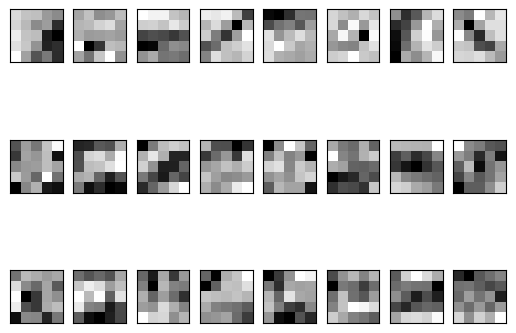

In [ ]:
conv1 = model[0]
conv2 = model[4]

fig, axes = plt.subplots(3, 8, sharex=True, sharey=True, subplot_kw={'xticklabels': '', 'yticklabels': '', 'xticks': (50,), 'yticks': (50,)})
with torch.no_grad():
    for idx, kernel in enumerate(conv1.weight):
        axes[0, idx].imshow(kernel[0], cmap='grey')
    for idx, kernel in enumerate(conv2.weight[:8]):
        axes[1, idx].imshow(kernel[0], cmap='grey')
    for idx, kernel in enumerate(conv2.weight[8:]):
        axes[2, idx].imshow(kernel[0], cmap='grey')


## Visualize each kernel's predictions

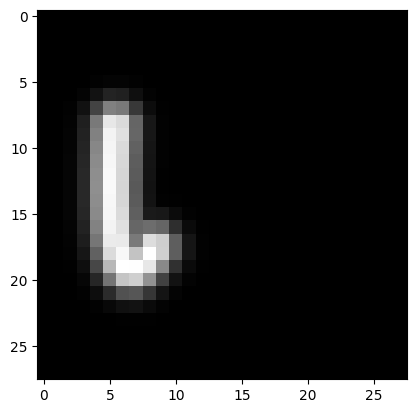

Model prediction:  blank


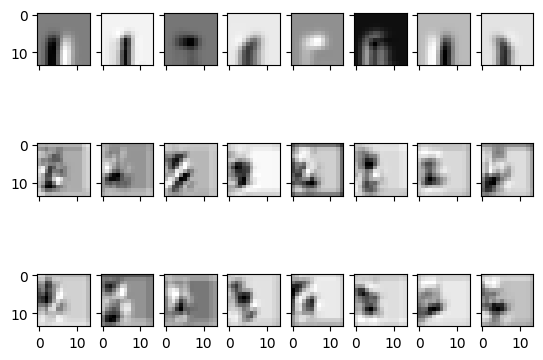

In [18]:
im: torch.Tensor = RandomLinesGenerator().generate(max_lines=1)
plt.imshow(im, cmap='gray')
plt.show()
im = im.unsqueeze(0).unsqueeze(0)
fig, axes = plt.subplots(3, 8, sharex=True, sharey=True, subplot_kw={'xticklabels': '', 'yticklabels': ''})

plt.cla()
model.eval()
with torch.no_grad():
    print('Model prediction: ', class_mapper[torch.argmax(torch.softmax(model(im), 1)).item()])
    conv1_output = model[0](im)
    conv1_bn = model[1](conv1_output)
    conv1_relu = model[2](conv1_bn)
    conv1_pool = model[3](conv1_relu)

    for idx, kernel in enumerate(conv1_output[0]):
        axes[0, idx].imshow(kernel, cmap='gray')
    
    conv2_output = model[4](conv1_pool)
    for idx, kernel in enumerate(conv2_output[0]):
        axes[idx // 8 + 1, idx % 8].imshow(kernel, cmap='gray')

plt.show()